In [1]:
import torch
import torch.nn as nn
from complex_layers import ComplexConv2d, ComplexTransposeConv2d, ComplexBatchNorm2d, ComplexReLU, ComplexAvgPool2d

# reference code

In [ ]:
import torch
import torch.nn as nn
from complex_layers import ComplexConv2d, ComplexTransposeConv2d, ComplexBatchNorm2d, ComplexReLU, ComplexAvgPool2d

#there are some logical building blocks
# 1. ComplexDoubleConv2D : [ComplexConv2d -> ComplexBatchNorm2d -> ComplexReLU] *2 
# 2. ComplexDownsample

# Input: Complex tensor (batch, coils, H, W) - complex valued

class ComplexDoubleConv2D(nn.Module):
    def __init__(self, input_ch, output_ch):
        super().__init__()

        self.conv1 = ComplexConv2d(input_ch, output_ch, k=3, s=1, p=1)
        self.bn1 = ComplexBatchNorm2d(output_ch)
        self.relu1 = ComplexReLU()
        
        self.conv2 = ComplexConv2d(output_ch, output_ch, k=3, s=1, p=1)
        self.bn2 = ComplexBatchNorm2d(output_ch)
        self.relu2 = ComplexReLU()
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        
        return x
    

class ComplexDownSample(nn.Module):
    def __init__(self, input_channels, output_channels, kernel_size=2, stride=2):
        super().__init__()
        
        self.pool = ComplexAvgPool2d(k=kernel_size, s=stride)
        self.double_conv = ComplexDoubleConv2D(input_channels, output_channels)
    
    def forward(self, x):
        x = self.pool(x)
        x = self.double_conv(x)
        return x
    


class ComplexUNET_encoder(nn.Module):
    def __init__(self, **params):
        super().__init__()

        self.first_double_conv = ComplexDoubleConv2D(15, 32)  # 15 coils input
        self.downsample1 = ComplexDownSample(32, 64)
        self.downsample2 = ComplexDownSample(64, 128)
        self.downsample3 = ComplexDownSample(128, 256)
        self.downsample4 = ComplexDownSample(256, 512)


    def forward(self, x):

        f1 = self.first_double_conv(x)
        f2 = self.downsample1(f1)
        f3 = self.downsample2(f2)
        f4 = self.downsample3(f3)
        bottleneck = self.downsample4(f4)

        return bottleneck, [f4, f3, f2, f1]
    

class ComplexUNET_decoder(nn.Module):
    def __init__(self, **params):
        super().__init__()

        self.tcv1 = ComplexTransposeConv2d(512, 256, k=2, s=2, p=0)
        self.double_conv1 = ComplexDoubleConv2D(512, 256)  # after concatenating the skip connection, the channels will be 1024

        self.tcv2 = ComplexTransposeConv2d(256, 128, k=2, s=2, p=0)
        self.double_conv2 = ComplexDoubleConv2D(256, 128)

        self.tcv3 = ComplexTransposeConv2d(128, 64, k=2, s=2, p=0)
        self.double_conv3 = ComplexDoubleConv2D(128, 64)

        self.tcv4 = ComplexTransposeConv2d(64, 32, k=2, s=2, p=0)
        self.double_conv4 = ComplexDoubleConv2D(64, 32)


    def forward(self, bottleneck, skip_conns_list):

        upsample_1 = self.tcv1(bottleneck)
        # now we need to concat with the skip connection
        concat_skip_1 = torch.concat([upsample_1, skip_conns_list[0]], dim=1)
        double_conv1_op = self.double_conv1(concat_skip_1)

        upsample_2 = self.tcv2(double_conv1_op)
        concat_skip_2 = torch.concat([upsample_2, skip_conns_list[1]], dim=1)
        double_conv2_op = self.double_conv2(concat_skip_2)

        upsample_3 = self.tcv3(double_conv2_op)
        concat_skip_3 = torch.concat([upsample_3, skip_conns_list[2]], dim=1)
        double_conv3_op = self.double_conv3(concat_skip_3)

        upsample_4 = self.tcv4(double_conv3_op)
        concat_skip_4 = torch.concat([upsample_4, skip_conns_list[3]], dim=1)
        double_conv4_op = self.double_conv4(concat_skip_4)

        return double_conv4_op
    


class UNET_final(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = ComplexUNET_encoder()
        self.decoder = ComplexUNET_decoder()
        self.one_cross_one_conv = ComplexConv2d(32, 15, k=1, s=1, p=0)  # 15 coils output

    def forward(self, x):
        bottleneck, skip_conns_list = self.encoder(x)
        final_conv_op = self.decoder(bottleneck, skip_conns_list)
        final_kspace = self.one_cross_one_conv(final_conv_op)

        return final_kspace


# training code

In [3]:
# !pip install torchmetrics
import updated_dataloader
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm  # Provides a nice progress bar
from fastmri.data.subsample import EquiSpacedMaskFunc
import glob
import os
from torchmetrics import StructuralSimilarityIndexMeasure, PeakSignalNoiseRatio

/home/biswamitra/health/yash/miniconda3/envs/biswa_env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# ==========================================
# 1. SETUP & HYPERPARAMETERS
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_epochs = 50
batch_size = 12
learning_rate = 2e-4
patience = 5

train_dir = "/home/biswamitra/health/knee_data/train/deconstructed_train/"
val_dir = "/home/biswamitra/health/knee_data/val/deconstructed_val/"
saved_model_path = "/home/biswamitra/health/knee_data/EDA/saved_model/complex_kspace_model.pth"

# ==========================================
# 2. DATALOADERS
# ==========================================
train_files = sorted(glob.glob(train_dir + "*.npy"))
val_files = sorted(glob.glob(val_dir + "*.npy"))

print(f"Found {len(train_files)} training files and {len(val_files)} validation files.")

mask_func = EquiSpacedMaskFunc(center_fractions=[0.08], accelerations=[20])

train_data = updated_dataloader.Custom_FMRI_DataLoader_nil(
    data_paths=train_files, mask_func=mask_func,
    input_req=[1,1,1,1,1], output_req=[1,1,1,1], methods_flags=[0,0]
)

val_data = updated_dataloader.Custom_FMRI_DataLoader_nil(
    data_paths=val_files, mask_func=mask_func,
    input_req=[1,1,1,1,1], output_req=[1,1,1,1], methods_flags=[0,0]
)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=8)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=8)

# ==========================================
# 3. MODEL, LOSS, & OPTIMIZER
# ==========================================
model = UNET_final()

if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs via nn.DataParallel!")
    model = nn.DataParallel(model)

model = model.to(device)

class SpecialLossFunc(nn.Module):
    def __init__(self, alpha=0.86):
        super().__init__()
        self.alpha = alpha
        self.l1_loss = nn.L1Loss()
        self.ssim = StructuralSimilarityIndexMeasure(data_range=1.0)

    def forward(self, preds, targets):
        l1_loss = self.l1_loss(preds, targets)
        ssim_val = self.ssim(preds, targets)
        ssim_loss = 1.0 - ssim_val
        hybrid_loss = (1.0 - self.alpha) * l1_loss + self.alpha * ssim_loss
        return hybrid_loss

loss_func = SpecialLossFunc().to(device)
psnr_module = PeakSignalNoiseRatio(data_range=1.0).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)


# ==========================================
# HELPER FUNCTIONS (UPDATED FOR COMPLEX TENSORS)
# ==========================================
def prepare_input(batch):
    """
    Takes masked_k_space (B, coils, H, W, 2) and converts to
    complex tensor (B, coils, H, W) for the complex UNet model.
    """
    x = batch['masked_k_space'].to(device, dtype=torch.float32)
    B, C, H, W, cr = x.shape                  # cr = 2 (real/imag)
    
    # Convert to complex tensor
    complex_x = torch.complex(x[..., 0], x[..., 1])  # (B, C, H, W) complex
    return complex_x

def apply_data_consistency(predicted_kspace_complex, original_kspace_complex):
    """
    Forces the network output to strictly match the originally sampled k-space lines.
    Both inputs are complex tensors.
    $k_{final} = M dot k_{masked} + (1 - M) dot k_{predicted}$
    """
    # The original k-space has zeros where the data was not sampled.
    # Create mask from non-zero elements
    mask = (torch.abs(original_kspace_complex) != 0.0).float()
    
    # Inject the true sampled lines back into the prediction
    dc_kspace = (original_kspace_complex * mask) + (predicted_kspace_complex * (1.0 - mask))
    return dc_kspace

def kspace_to_rss(kspace_complex):
    """
    Takes complex k-space tensor (B, coils, H, W), applies proper center shifts and iFFT,
    and returns RSS-combined magnitude image (B, 1, H, W).
    """
    # Input is already complex: (B, C, H, W) with dtype torch.complex
    
    # 1. Shift frequencies to origin [0,0]
    complex_shifted = torch.fft.ifftshift(kspace_complex, dim=(-2, -1))
    
    # 2. Inverse FFT
    image_complex = torch.fft.ifft2(complex_shifted, dim=(-2, -1), norm="ortho")
    
    # 3. Shift the image back to the visual center
    image_complex = torch.fft.fftshift(image_complex, dim=(-2, -1))
    
    # 4. RSS combination
    image_mag = torch.abs(image_complex)
    rss = torch.sqrt(torch.sum(image_mag ** 2, dim=1))  # (B, H, W)
    return rss.unsqueeze(1)  # (B, 1, H, W)


# ==========================================
# 4. TRAINING & VALIDATION LOOP
# ==========================================
trigger_times = 0
best_val_loss = float('inf')

for epoch in range(num_epochs):

    # ---------- TRAINING ----------
    model.train()
    running_train_loss = 0.0
    running_train_psnr = 0.0

    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")

    for batch in train_loop:
        input_tensor = prepare_input(batch)  # Now returns complex tensor
        target_tensor = batch['full_rss_combined'].unsqueeze(1).to(device, dtype=torch.float32)

        # 1. Normalize BEFORE passing to the model
        batch_max = target_tensor.max()
        if batch_max > 0:
            input_tensor = input_tensor / batch_max
            target_tensor = target_tensor / batch_max

        # 2. Forward pass (U-Net predicts full normalized k-space as complex tensor)
        predictions = model(input_tensor)
        # print("pred shape: ",predictions.shape)
        # print("input tensor shape: ",input_tensor.shape)
        # 3. Apply Data Consistency block
        if predictions.shape[-1] == 2 and not predictions.is_complex():
            predictions = torch.view_as_complex(predictions.contiguous())
        predictions = apply_data_consistency(predictions, input_tensor)

        # 4. Transform to Image Space
        final_images_pred = kspace_to_rss(predictions)

        # 5. Calculate Loss
        loss = loss_func(target_tensor, final_images_pred)

        # 6. Backpropagate
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

        with torch.no_grad():
            psnr_val = psnr_module(final_images_pred, target_tensor)
            running_train_psnr += psnr_val.item()

        # Update progress bar with running averages for stability
        train_loop.set_postfix(
            avg_loss=running_train_loss / (train_loop.n + 1), 
            avg_psnr=running_train_psnr / (train_loop.n + 1)
        )

    avg_train_loss = running_train_loss / len(train_loader)
    avg_train_psnr = running_train_psnr / len(train_loader)

    # ---------- VALIDATION ----------
    model.eval()
    running_val_loss = 0.0
    running_val_psnr = 0.0

    with torch.no_grad():
        val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]")

        for batch in val_loop:
            input_tensor = prepare_input(batch)  # Returns complex tensor
            target_tensor = batch['full_rss_combined'].unsqueeze(1).to(device, dtype=torch.float32)

            # Normalize
            batch_max = target_tensor.max()
            if batch_max > 0:
                input_tensor = input_tensor / batch_max
                target_tensor = target_tensor / batch_max

            # Forward Pass & DC Block
            predictions = model(input_tensor)
            predictions = apply_data_consistency(predictions, input_tensor)
            
            # Transform
            final_images_pred = kspace_to_rss(predictions)

            # Metrics
            val_loss = loss_func(target_tensor, final_images_pred)
            running_val_loss += val_loss.item()

            psnr_val = psnr_module(final_images_pred, target_tensor)
            running_val_psnr += psnr_val.item()

            val_loop.set_postfix(
                avg_val_loss=running_val_loss / (val_loop.n + 1), 
                avg_psnr=running_val_psnr / (val_loop.n + 1)
            )

    avg_val_loss = running_val_loss / len(val_loader)
    avg_val_psnr = running_val_psnr / len(val_loader)

    print(f"\nEpoch {epoch+1} Summary | "
          f"Train Loss: {avg_train_loss:.4f} | Train PSNR: {avg_train_psnr:.2f} dB | "
          f"Val Loss: {avg_val_loss:.4f} | Val PSNR: {avg_val_psnr:.2f} dB")

    # ---------- EARLY STOPPING & SAVING ----------
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        trigger_times = 0

        if isinstance(model, nn.DataParallel):
            torch.save(model.module.state_dict(), saved_model_path)
        else:
            torch.save(model.state_dict(), saved_model_path)

        print(f"--> Best model saved! (Val Loss: {best_val_loss:.4f})\n")
    else:
        trigger_times += 1
        print(f"--> No improvement. Early stopping trigger: {trigger_times} / {patience}\n")

        if trigger_times >= patience:
            print(f"Early stopping triggered! Training halted at epoch {epoch+1}.")
            break


Found 34742 training files and 7135 validation files.
Using 2 GPUs via nn.DataParallel!


/home/biswamitra/health/yash/miniconda3/envs/biswa_env/lib/python3.13/site-packages/torchmetrics/utilities/prints.py:62: FutureWarning: Importing `StructuralSimilarityIndexMeasure` from `torchmetrics` was deprecated and will be removed in 2.0. Import `StructuralSimilarityIndexMeasure` from `torchmetrics.image` instead.
  _future_warning(
/home/biswamitra/health/yash/miniconda3/envs/biswa_env/lib/python3.13/site-packages/torchmetrics/utilities/prints.py:62: FutureWarning: Importing `PeakSignalNoiseRatio` from `torchmetrics` was deprecated and will be removed in 2.0. Import `PeakSignalNoiseRatio` from `torchmetrics.image` instead.
  _future_warning(
Epoch 1/50 [Train]:   0%|          | 0/2896 [00:09<?, ?it/s]


RuntimeError: Function GatherBackward returned an invalid gradient at index 0 - got [6, 15, 640, 368, 2] but expected shape compatible with [6, 15, 640, 368]

# testing code

Loading model architecture and weights...
Model loaded successfully!
Running inference...
Baseline PSNR (Zero-Filled): 26.22 dB
Model PSNR (Prediction):     28.03 dB
Model SSIM:                  0.7344


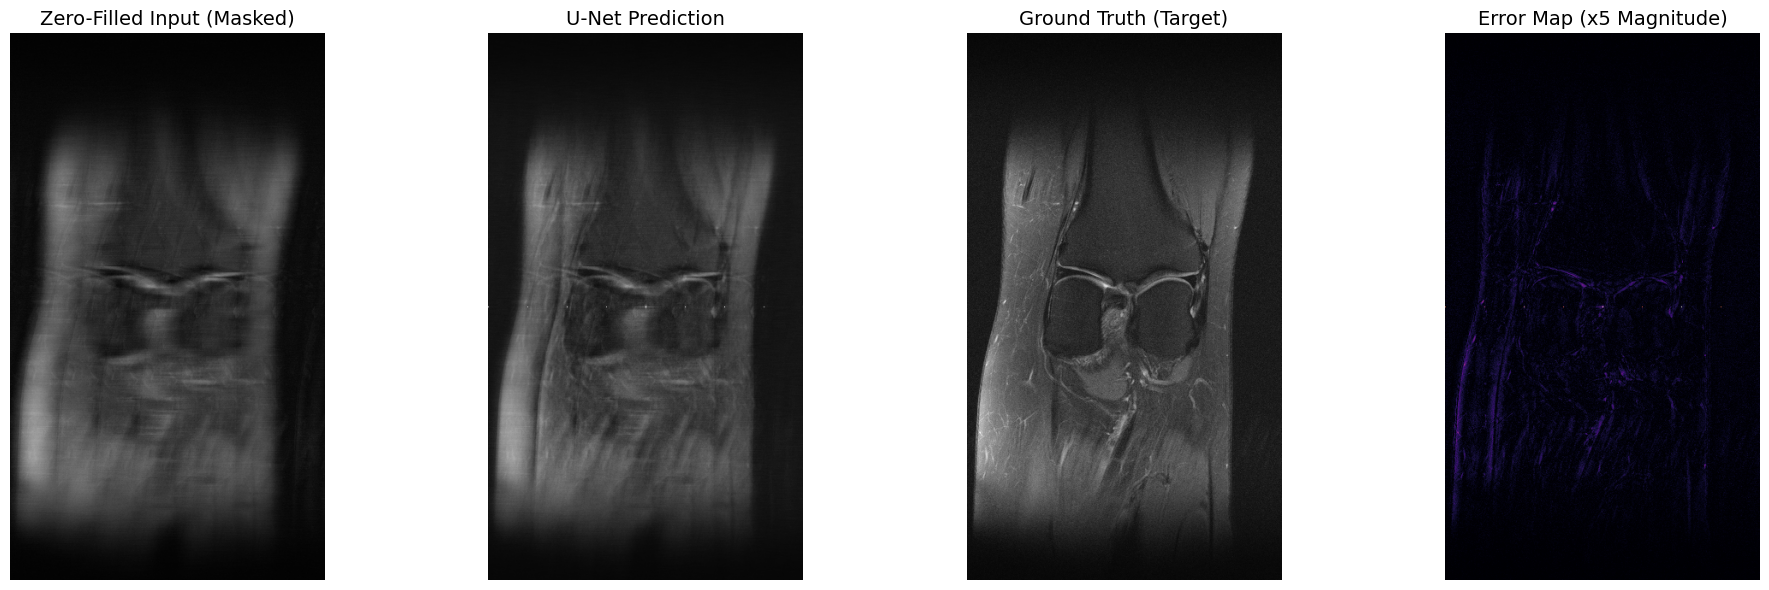

In [ ]:
import os
import sys
import glob
import torch
import numpy as np
import matplotlib.pyplot as plt

from fastmri.data.subsample import EquiSpacedMaskFunc

from kspace_complex_multigpu import (
    UNET_final,
    prepare_input,
    prepare_target_kspace,
    apply_data_consistency,
    kspace_to_rss
)

import updated_dataloader

def visualize_reconstruction():
    # 1. Setup Device & Paths
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    val_dir = "/home/biswamitra/health/knee_data/val/deconstructed_val/"
    saved_model_path = "/home/biswamitra/health/knee_data/EDA/saved_model/complex_kspace_model_ret.pth"

    # 2. Load the Model
    print("Loading model architecture and weights...")
    model = UNET_final().to(device)
    
    # We use map_location to ensure it loads cleanly even if trained on multi-GPU
    state_dict = torch.load(saved_model_path, map_location=device, weights_only=True)
    model.load_state_dict(state_dict)
    model.eval()
    print("Model loaded successfully!")

    # 3. Setup DataLoader (Just grab one batch for visualization)
    val_files = sorted(glob.glob(os.path.join(val_dir, "*.npy")))
    mask_func = EquiSpacedMaskFunc(center_fractions=[0.08, 0.04], accelerations=[4, 8])

    val_data = updated_dataloader.Custom_FMRI_DataLoader_nil(
        data_paths=val_files,
        mask_func=mask_func,
        input_req=[1, 1, 1, 1, 1],
        output_req=[1, 1, 1, 1],
        methods_flags=[0, 0],
    )

    # Batch size of 1 is enough for visual inspection
    val_loader = torch.utils.data.DataLoader(val_data, batch_size=1, shuffle=True)
    
    # Grab the first batch
    batch = next(iter(val_loader))

    # 4. Run the Forward Pass
    print("Running inference...")
    with torch.no_grad():
        # Fetch data
        input_kspace = prepare_input(batch, device)
        target_rss = batch["full_rss_combined"].unsqueeze(1).to(device, dtype=torch.float32)

        # 1. Scale input by its K-space max
        k_max = torch.abs(input_kspace).amax(dim=(1, 2, 3), keepdim=True)
        k_max[k_max == 0] = 1.0 
        
        input_norm = input_kspace / k_max

        # 2. Forward Pass (Model expects normalized k-space)
        pred_norm = model(input_norm)
        pred_norm = apply_data_consistency(pred_norm, input_norm)
        
        # 3. UNSCALE back to physical K-space BEFORE taking the FFT
        pred_real = pred_norm * k_max
        
        # 4. Convert to Image Space (RSS)
        final_images_pred = kspace_to_rss(pred_real)
        input_images_zf = kspace_to_rss(input_kspace) 

        # 5. Normalize Image Space strictly for accurate PSNR/SSIM and Plotting
        i_max = target_rss.amax(dim=(1, 2, 3), keepdim=True)
        i_max[i_max == 0] = 1.0
        
        pred_rss_norm = final_images_pred / i_max
        zf_rss_norm = input_images_zf / i_max
        target_rss_norm = target_rss / i_max

        # 6. Calculate Metrics
        psnr_module = PeakSignalNoiseRatio(data_range=1.0).to(device)
        ssim_module = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
        
        print(f"Baseline PSNR (Zero-Filled): {psnr_module(zf_rss_norm, target_rss_norm).item():.2f} dB")
        print(f"Model PSNR (Prediction):     {psnr_module(pred_rss_norm, target_rss_norm).item():.2f} dB")
        print(f"Model SSIM:                  {ssim_module(pred_rss_norm, target_rss_norm).item():.4f}")

    # 5. Extract Tensors to NumPy for Matplotlib (Using the newly normalized images!)
    gt_img = target_rss_norm[0, 0].cpu().numpy()
    pred_img = pred_rss_norm[0, 0].cpu().numpy()
    zf_img = zf_rss_norm[0, 0].cpu().numpy()

    # Calculate absolute error map (multiplied by 5 to make subtle errors visible)
    error_map = np.abs(gt_img - pred_img) 

    # 6. Plotting
    fig, axes = plt.subplots(1, 4, figsize=(20, 6))
    
    # Set a consistent color map and scaling across all images
    vmax = np.max(gt_img)
    cmap = 'gray'

    ax = axes[0]
    ax.imshow(zf_img, cmap=cmap, vmin=0, vmax=vmax)
    ax.set_title("Zero-Filled Input (Masked)", fontsize=14)
    ax.axis('off')

    ax = axes[1]
    ax.imshow(pred_img, cmap=cmap, vmin=0, vmax=vmax)
    ax.set_title("U-Net Prediction", fontsize=14)
    ax.axis('off')

    ax = axes[2]
    ax.imshow(gt_img, cmap=cmap, vmin=0, vmax=vmax)
    ax.set_title("Ground Truth (Target)", fontsize=14)
    ax.axis('off')

    ax = axes[3]
    # Error maps are usually shown in a heatmap like 'inferno' or 'magma'
    im = ax.imshow(error_map, cmap='magma', vmin=0, vmax=vmax) 
    ax.set_title("Error Map (x5 Magnitude)", fontsize=14)
    ax.axis('off')

    plt.tight_layout()
    plt.show()


visualize_reconstruction()  

In [ ]:
test_dir = "/home/biswamitra/health/knee_data/val/deconstructed_val/"
model_path = "/home/biswamitra/health/knee_data/EDA/saved_model/complex_kspace_model.pth"

